In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import DualMap
from branca.element import Element

In [2]:
gdf = gpd.read_file("data/louisiana2026.geojson")

# EPSG must be set to 4326 for folium
print(gdf.crs)
gdf = gdf.to_crs("EPSG:4326")

gdf.head()

EPSG:4269


,OBJECTID,DISTRICT_I,NAME,NUM_MEMBER,IDEAL_POP,IS_LOCKED,SHAPE_AREA,SHAPE_LEN,G24PREDHAR,G24PRERTRU,2024DPct,2024RPct,Margin,geometry
0,1,1,District 1,1,776292,0,2.206914,13.249303,102921,234279,0.305222,0.694778,-38.955516,"POLYGON ((-90.25170 30.71172, -90.24707 30.710..."
1,2,2,District 2,1,776292,0,0.283721,7.248457,217199,74397,0.744863,0.255137,48.972551,"POLYGON ((-91.16473 30.58425, -91.16444 30.584..."
2,3,3,District 3,1,776292,0,2.311270,11.137485,104323,223456,0.318272,0.681728,-36.345525,"POLYGON ((-91.78509 30.69264, -91.78492 30.692..."
3,4,4,District 4,1,776292,0,3.271381,15.821837,102243,206563,0.331091,0.668909,-33.781727,"POLYGON ((-93.90428 33.01957, -93.90115 33.019..."
4,5,5,District 5,1,776292,0,3.776345,19.782514,101495,206180,0.329877,0.670123,-34.024539,"POLYGON ((-92.04496 33.00775, -92.03709 33.007..."


KeyError: 'Margin New'

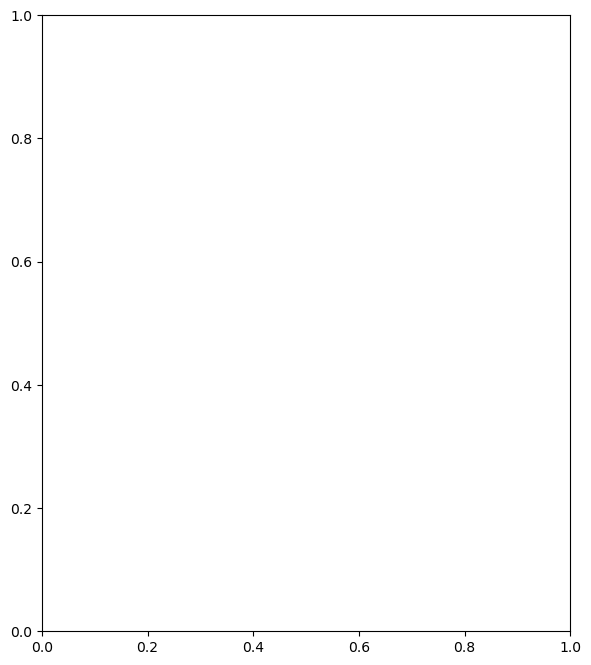

In [3]:
# test choropleth map using matplotlib
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create the choropleth map
gdf.plot(
    column='Margin New', 
    cmap='RdBu',            # Choose a colormap
    legend=True,              # Show the color scale
    legend_kwds={'label': '2024 Harris-Trump % Margin', 'orientation': 'horizontal'},
    edgecolor='black',        # Outline districts
    ax=ax
)

# Remove axes for a cleaner map look
ax.axis('off')

# Display the map
plt.show()

In [ ]:
# Initialize the DualMap centered directly over Louisiana
# Zoom level 7 perfectly captures the entire state from Shreveport down to the Delta
m = DualMap(location=[31.0, -92.0], zoom_start=7, tiles="CartoDB positron")

# set minimum and maximum zoom distance
for sub_map in [m.m1, m.m2]:
    sub_map.options['minZoom'] = 6
    sub_map.options['maxZoom'] = 9

In [ ]:
# Inject CSS to turn the background container perfectly solid white 
# This eliminates Leaflet's default gray "empty grid" texture lines
css_cleaner = Element("""
<style>
    .leaflet-container {
        background: #ffffff !important;
    }
</style>
""")
m.get_root().header.add_child(css_cleaner)

In [ ]:
# Left Map Color Scheme 
def style_left(feature):
    # Swap 'pres_margin_2024' with your actual column name
    margin = feature['properties'].get('Margin New', 0)
    
    # Diverging color scale (Blue for Dem, Red for Rep) based on margin intensity
    if margin >= 0.30:     color = '#084594'  # Deep Blue (Dem +20% or more)
    elif margin >= 0.15:   color = '#4292c6'  # Medium Blue (Dem +5% to +20%)
    elif margin > 0:       color = '#9ecae1'  # Light Blue (Dem under +5%)
    elif margin >= -0.15:  color = '#fcae91'  # Light Red (Rep under +5%)
    elif margin >= -0.30:  color = '#maroon'  # Medium Red (Rep +5% to +20%)
    else:                  color = '#cb181d'  # Deep Red (Rep +20% or more)
        
    return {
        'fillColor': color,
        'color': '#454545',   # Muted dark gray border for districts
        'weight': 1.5,
        'fillOpacity': 0.8
    }

# Right Map Color Scheme (Example: Metric B - Political Margin or Demographic Share)
def style_right(feature):
    # Swap 'turnout_2026' with your alternative column name 
    margin = feature['properties'].get('Margin New', 0)
    
    if margin >= 0.30:     color = '#084594'  # Deep Blue (Dem +20% or more)
    elif margin >= 0.15:   color = '#4292c6'  # Medium Blue (Dem +5% to +20%)
    elif margin > 0:       color = '#9ecae1'  # Light Blue (Dem under +5%)
    elif margin >= -0.15:  color = '#fcae91'  # Light Red (Rep under +5%)
    elif margin >= -0.30:  color = '#ef3b2c'  # Medium Red (Rep +5% to +20%)
    else:                  color = '#cb181d'  # Deep Red (Rep +20% or more)
        
    return {
        'fillColor': color,
        'color': '#454545',   # Muted dark gray border for districts
        'weight': 1.5,
        'fillOpacity': 0.8
    }

In [ ]:
# Bind the Louisiana geometry & tooltips to each side
# Adjust 'DISTRICT' or 'CD118FP' depending on your file's specific ID column
folium.GeoJson(
    gdf,
    style_function=style_left,
    tooltip=folium.GeoJsonTooltip(
        fields=['District No.', 'Margin'], 
        aliases=['District:', '2024 Harris-Trump Margin:']
    )
).add_to(m.m1)

folium.GeoJson(
    gdf,
    style_function=style_right,
    tooltip=folium.GeoJsonTooltip(
        fields=['District No.', 'Margin'], 
        aliases=['District:', '2024 Pres. Margin Shift from 2024 Boundaries:']
    )
).add_to(m.m2)

# 7. Create custom web panes to force the labels onto the very top layer
# This ensures district colors don't mask or cover up the city text
pane_left = folium.map.CustomPane("labels_left", z_index=450).add_to(m.m1)
pane_right = folium.map.CustomPane("labels_right", z_index=450).add_to(m.m2)

# 8. Inject the transparent city label tiles into the top panes
# These tiles contain ONLY text strings (cities, water body names, highway labels) with no land/road art
folium.TileLayer("cartodbpositrononlylabels", pane="labels_left").add_to(m.m1)
folium.TileLayer("cartodbpositrononlylabels", pane="labels_right").add_to(m.m2)

m

In [ ]:
# Create the interactive map and define the choropleth column
# Note: In newer versions, 'gpd.datasets.get_path()' is deprecated in favor of just using the dataset name directly
# m = district_gdf.explore(
#      column='Margin', 
#      tiles=None,
#      style_kwds=dict(
#         color='black',
#         fillOpacity=0.8,   # Semi-transparent fill
#         opacity=1.0,       # Mostly opaque border lines
#         weight=1           # Border line thickness
#      ),
#      cmap='RdBu', # Color map
#      legend=True, # Show map legend
#      tooltip=['NAME', 'Margin'], # Fields to display on hover
#      popup=True # Show clickable details
# )

# m